# Employee Salary Prediction Using Machine Learning

## Project Description
This project aims to build a machine learning model that predicts employee income based on factors such as age and years of experience. The purpose is to understand how employee attributes influence salary patterns and use supervised learning algorithms to make accurate predictions.

The project covers data understanding, exploratory data analysis, model training, evaluation, and drawing insights from the dataset.

## Importing Required Libraries

We import libraries required for data handling, visualization, model building, and evaluation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading Dataset

The dataset contains employee information including age, experience, and income. We first load and inspect the data.

In [2]:
df = pd.read_csv('employee_income.csv')
df.head()

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


### Dataset Overview
This step checks dataset size, column information, and missing values to understand data quality.

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         50 non-null     int64
 1   experience  50 non-null     int64
 2   income      50 non-null     int64
dtypes: int64(3)
memory usage: 1.3 KB


age           0
experience    0
income        0
dtype: int64


The dataset contains numerical features and can be directly used for regression after checking data quality.

## Exploratory Data Analysis

EDA helps us understand patterns and relationships between employee attributes and income.

## Distribution of Income

This visualization shows how employee incomes are distributed. It helps identify the common salary range and whether extreme values exist.

c:\Users\kesha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


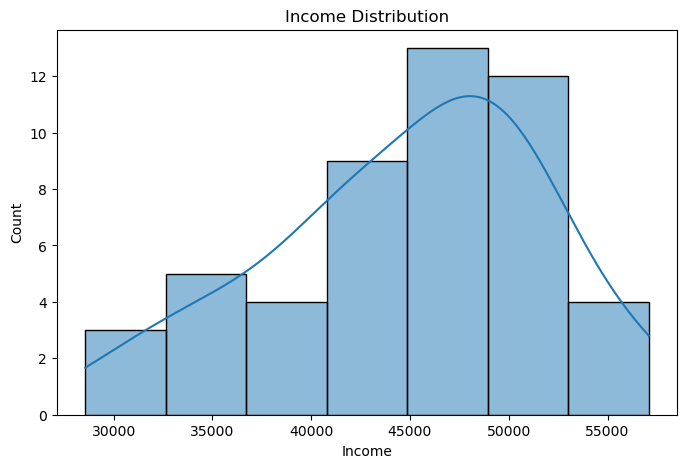

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.show()


The income distribution shows the salary range present in the dataset and helps understand the overall salary pattern.

## Experience vs Income

This plot shows the relationship between years of experience and employee income. It helps determine whether experience has a positive impact on salary.

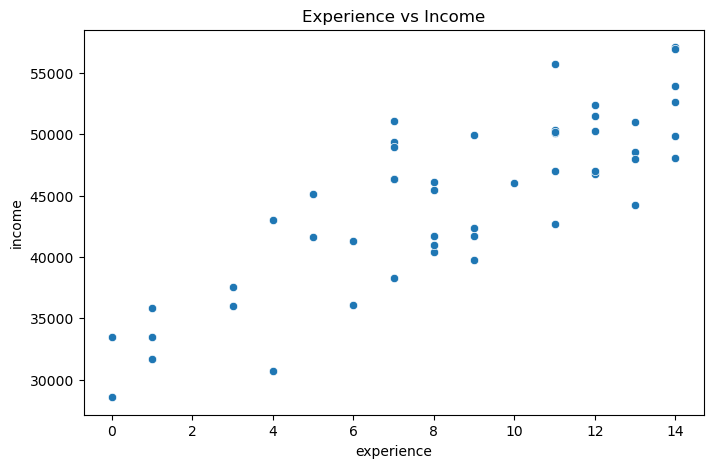

In [5]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='experience', y='income')
plt.title('Experience vs Income')
plt.show()


The plot helps identify whether employees with more experience generally earn higher income.

## Correlation Analysis

Correlation measures the strength of relationships between numerical variables. It helps identify which features influence income.

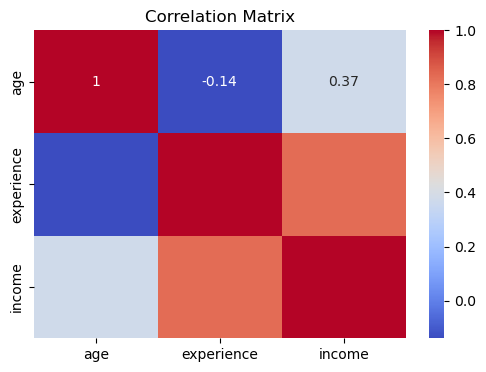

In [6]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


Correlation analysis shows how strongly age and experience are related to income and helps in feature selection.

## Model Building

We train regression models to predict employee income using available features.

In [7]:
X=df[['age','experience']]
y=df['income']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Linear Regression Model

Linear Regression predicts income by learning the relationship between input features and salary.

In [8]:
lr=LinearRegression()
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)

## Random Forest Regression Model

Random Forest uses multiple decision trees to improve prediction performance and capture complex patterns.

In [9]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)

## Model Evaluation

Evaluation metrics measure how accurately the models predict employee income.

In [10]:
def evaluate(y_test,pred):
    print('MAE:',mean_absolute_error(y_test,pred))
    print('MSE:',mean_squared_error(y_test,pred))
    print('R2 Score:',r2_score(y_test,pred))

print('Linear Regression')
evaluate(y_test,lr_pred)

print('\nRandom Forest')
evaluate(y_test,rf_pred)

Linear Regression
MAE: 1581.4121026423527
MSE: 3061367.451388377
R2 Score: 0.9349274275513149

Random Forest
MAE: 2344.71
MSE: 8455624.06952
R2 Score: 0.8202668517909706


## Actual vs Predicted Income

This visualization compares actual income values with predicted values to understand model performance.

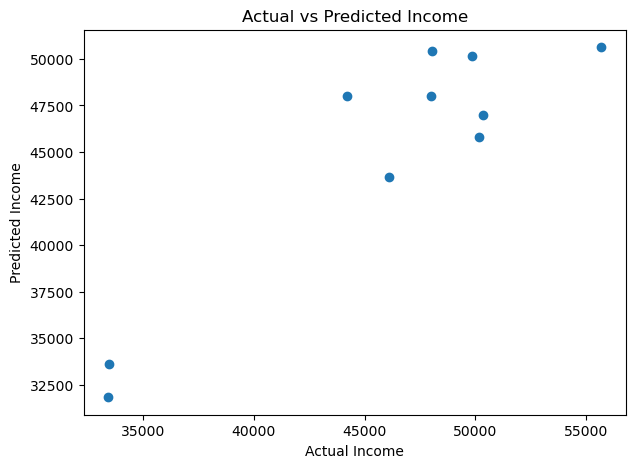

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, rf_pred)
plt.xlabel('Actual Income')
plt.ylabel('Predicted Income')
plt.title('Actual vs Predicted Income')
plt.show()

## Final Project Conclusion

The Employee Salary Prediction project demonstrates how machine learning can be used to predict salaries from employee characteristics.

Main observations:
- Experience is an important factor affecting employee income.
- Data visualization helps understand salary trends and relationships.
- Regression algorithms can successfully predict continuous salary values.
- Model evaluation metrics such as MAE, MSE, and R2 Score help compare performance.
- Machine learning can support salary estimation and decision-making in organizations.